Dataset loaded with 50000 vulnerabilities
Evaluating Models (Converting sparse to dense where needed)...
Finished Lasso (L1): MAE = 2.5011
Finished Elastic Net: MAE = 2.5010
Finished Bayesian Ridge: MAE = 2.5010
Finished XGBoost: MAE = 2.5044


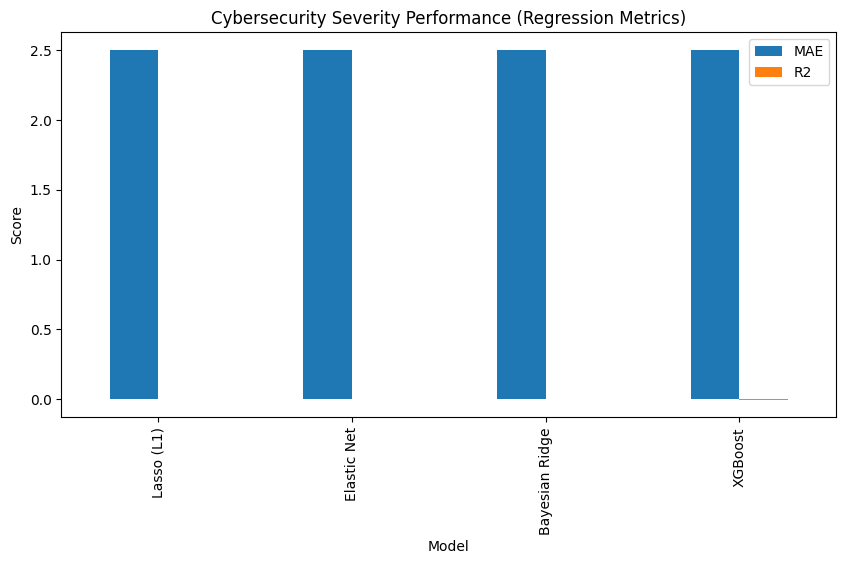

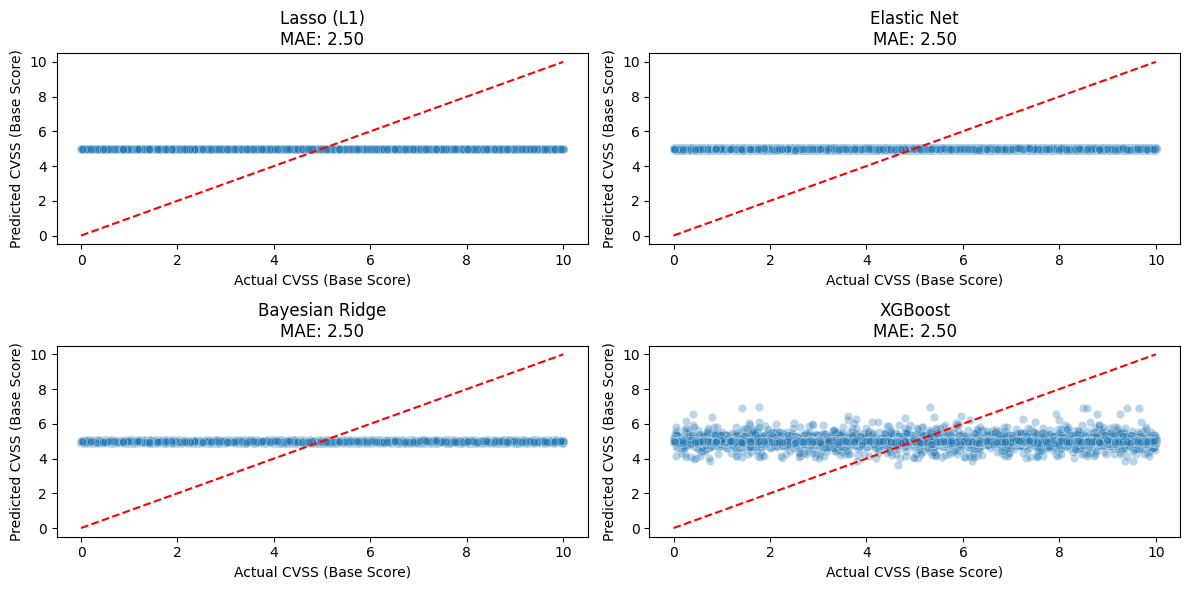

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

# Machine Learning Frameworks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.linear_model import Lasso, ElasticNet, BayesianRidge
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

# 1 Representing the NVD Dataset Structure
nrows = 50000

def generate_cyber_data():
    cwes = [f"CWE-{i}" for i in range (1, 201)]
    data = {
        'cve_id': [f"CVE-2023-{i}"for i in range (nrows)],
        'cwe_id': np.random.choice (cwes, nrows, p=[(1/i)/sum([1/j for j in range(1, 201)]) for i in range (1, 201)]),
        'attack_vector': np.random.choice (['Network', 'Adjacent', 'Local', 'Physical'], nrows),
        'complexity': np.random.choice (['Low', 'High'], nrows),
        'severity': np.random.choice ([0, 1, 2, 3], nrows, p=[0.1, 0.4, 0.4, 0.1]),
        'base_score': np.random.uniform (0.0, 10.0, nrows)
    }
    return pd.DataFrame(data)

df = generate_cyber_data()
print (f"Dataset loaded with {df.shape[0]} vulnerabilities")

# 2 Handling Sparsity
encoder = OneHotEncoder (sparse_output=True, handle_unknown='ignore')
X_sparse_regression = encoder.fit_transform (df[['cwe_id', 'attack_vector', 'complexity']])
y = df ['base_score']

# Splitting the Data
X_train, X_test, y_train, y_test = train_test_split (X_sparse_regression, y, test_size=0.2, random_state=42)

# 3 Implementing the 4 Regression Techniques
lasso = Lasso (alpha=0.01, random_state=42)
enet = ElasticNet (alpha=0.01, l1_ratio=0.5, random_state=42)
bayesian = BayesianRidge()
xgb_reg = xgb.XGBRegressor (tree_method='hist', n_estimators=100, learning_rate=0.1, random_state=42)

models = {"Lasso (L1)": lasso, "Elastic Net": enet, "Bayesian Ridge": bayesian, "XGBoost": xgb_reg}

# 4 Execution and Evaluation
results = {}
print ("Evaluating Models (Converting sparse to dense where needed)...")

# Converting to dense for models like BayesianRidge that require it
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

for name, model in models.items():
  # We use dense data to avoid TypeError for BayesianRidge
  model.fit (X_train_dense, y_train)
  preds = model.predict (X_test_dense)
  mae = mean_absolute_error (y_test, preds)
  r2 = r2_score (y_test, preds)
  results [name] = {'MAE': mae, 'R2': r2, 'Predictions': preds}
  print (f"Finished {name}: MAE = {mae:.4f}")

# 5 Visualisation
results_df = pd.DataFrame([{'Model': k, 'MAE': v['MAE'], 'R2': v['R2']} for k, v in results.items()])
results_df.set_index('Model').plot(kind='bar', figsize=(10, 5))
plt.title ("Cybersecurity Severity Performance (Regression Metrics)")
plt.ylabel ("Score")
plt.figure (figsize = (12, 6))
for i, (name, metrics) in enumerate (results.items()):
  plt.subplot (2, 2, i + 1)
  sns.scatterplot (x=y_test, y=metrics['Predictions'], alpha=0.3)
  plt.plot ([0, 10], [0, 10], color='red', linestyle='--')
  plt.title (f"{name}\nMAE: {metrics['MAE']:.2f}")
  plt.xlabel ("Actual CVSS (Base Score)")
  plt.ylabel ("Predicted CVSS (Base Score)")

plt.tight_layout ()
plt.show ()